# Section 1: Initial Setup

In [ ]:
from google.colab import drive
import os

root_dir = '/content/drive/'
work_dir = root_dir + ''


drive. mount(root_dir, force_remount=True)

os.chdir(work_dir)
os.getcwd()
print (sorted(os.listdir()))

In [ ]:
# Install required libraries
!pip install --upgrade nltk spacy whoosh textblob matplotlib seaborn vaderSentiment bertopic

In [ ]:
# Standard libraries import and download of resources
# Import libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob

# Download nltk resources
nltk.download('punkt')
nltk.download("punkt_tab")
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Section 2: Dataset and Dataset Anaysis
# Section 2.1 Dataset Sampling

Businesses shape: (150346, 14)
Reviews shape: (200002, 9)
Selected area: Santa Barbara
Businesses: 3829
Reviews: 7395
Average Stars: 4.0386747802569305
Average Review Length: 515.4058147396889


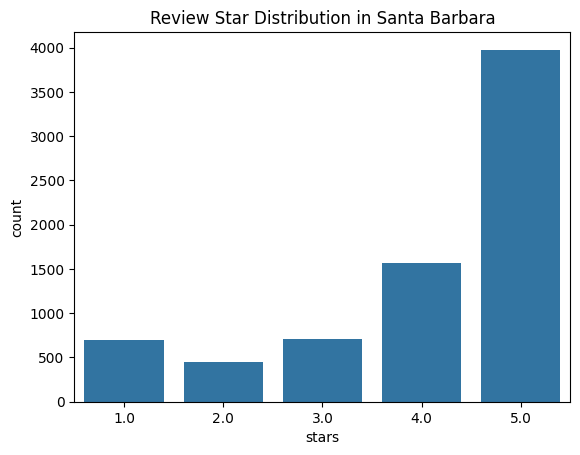

In [ ]:
# Load Yelp Dataset
# (business.json and review.json)

# Path to dataset
business_path = "dataset/yelp_academic_dataset_business.json"
review_path   = "dataset/yelp_academic_dataset_review.json"

# Load businesses
businesses = []
with open(business_path, "r", encoding="utf-8") as f:
    for line in f:
        businesses.append(json.loads(line))
business_df = pd.DataFrame(businesses)

# Load reviews
reviews = []
with open(review_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        reviews.append(json.loads(line))
        if i > 200000:  # load first 200k reviews to keep things manageable
            break
review_df = pd.DataFrame(reviews)

print("Businesses shape:", business_df.shape)
print("Reviews shape:", review_df.shape)

# Filter by Metropolitan Area
# Choose "Santa Barbara"
selected_city = "Santa Barbara"
business_subset = business_df[business_df["city"] == selected_city]

# Filter reviews belonging to these businesses
business_ids = set(business_subset["business_id"])
review_subset = review_df[review_df["business_id"].isin(business_ids)]

print(f"Selected area: {selected_city}")
print("Businesses:", len(business_subset))
print("Reviews:", len(review_subset))

# Basic Statistics
print("Average Stars:", review_subset["stars"].mean())
print("Average Review Length:", review_subset["text"].apply(len).mean())

# Distribution of stars
sns.countplot(x="stars", data=review_subset)
plt.title(f"Review Star Distribution in {selected_city}")
plt.show()

# Section 2.2: Tokenization and Stemming

Selected area: Santa Barbara
Businesses: 3829
Reviews: 7395
Selected Business: Breakfast Culture Club (Business ID: O6RCCmz8-x4NhWJpI8KQug)
Number of reviews for b1: 36
Total tokens after cleaning: 1812


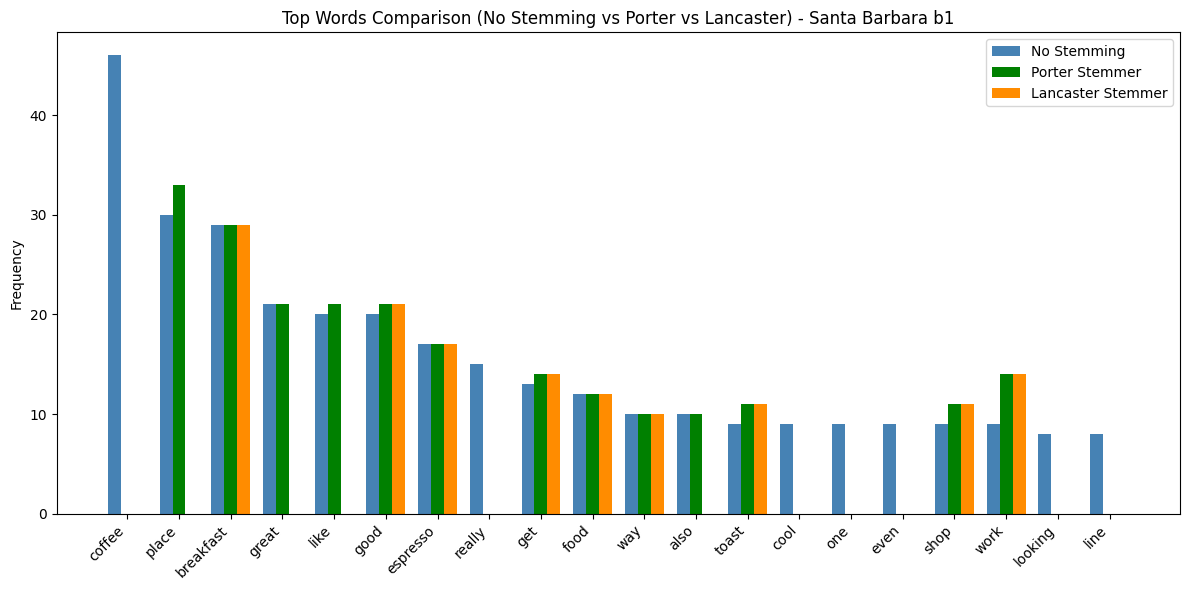

In [ ]:
# Tokenization + Stemming (Santa Barbara, safe version)
# Uses RegexpTokenizer

import nltk
from nltk.stem import PorterStemmer, LancasterStemmer
from collections import Counter
from nltk.tokenize import RegexpTokenizer
import seaborn as sns
import numpy as np

# Filter dataset to Santa Barbara
selected_city = "Santa Barbara"
business_subset = business_df[business_df["city"] == selected_city]
business_ids = set(business_subset["business_id"])
review_subset = review_df[review_df["business_id"].isin(business_ids)]

print(f"Selected area: {selected_city}")
print("Businesses:", len(business_subset))
print("Reviews:", len(review_subset))

# Pick a random business with >=5 reviews
valid_businesses = [
    bid for bid in business_subset["business_id"]
    if len(review_subset[review_subset["business_id"] == bid]) >= 5
]

if not valid_businesses:
    raise ValueError("No businesses in Santa Barbara with at least 5 reviews!")

b1 = random.choice(valid_businesses)
b1_reviews = review_subset[review_subset["business_id"] == b1]["text"].tolist()
b1_name = business_df.loc[business_df["business_id"] == b1, "name"].values[0]

print(f"Selected Business: {b1_name} (Business ID: {b1})")
print(f"Number of reviews for b1: {len(b1_reviews)}")

# Concatenate all reviews of b1
b1_text = " ".join(b1_reviews)

# Tokenization (Regex, avoids punkt errors)
tokenizer = RegexpTokenizer(r'\w+')
tokens = tokenizer.tokenize(b1_text.lower())

# Remove stopwords
stop_words = set(stopwords.words("english"))
tokens = [t for t in tokens if t not in stop_words]

print("Total tokens after cleaning:", len(tokens))

# Apply two stemmers
porter = PorterStemmer()
lancaster = LancasterStemmer()

porter_tokens = [porter.stem(t) for t in tokens]
lancaster_tokens = [lancaster.stem(t) for t in tokens]

def plot_combined_top_words(tokens_no, tokens_porter, tokens_lancaster, n=20):
    # Compute top-n frequencies
    freq_no = Counter(tokens_no).most_common(n)
    freq_porter = Counter(tokens_porter).most_common(n)
    freq_lancaster = Counter(tokens_lancaster).most_common(n)

    # Convert to dictionaries for lookup
    dict_no = dict(freq_no)
    dict_porter = dict(freq_porter)
    dict_lancaster = dict(freq_lancaster)

    # Collect all unique words across all stemmers
    all_words = list(set(dict_no.keys()) | set(dict_porter.keys()) | set(dict_lancaster.keys()))
    # Sort roughly by original (no-stemming) frequency
    all_words = sorted(all_words, key=lambda x: dict_no.get(x, 0), reverse=True)[:n]

    # Prepare aligned counts
    no_counts = [dict_no.get(w, 0) for w in all_words]
    porter_counts = [dict_porter.get(w, 0) for w in all_words]
    lancaster_counts = [dict_lancaster.get(w, 0) for w in all_words]

    # Bar positions
    x = np.arange(len(all_words))
    width = 0.25  # bar width

    plt.figure(figsize=(12,6))
    plt.bar(x - width, no_counts, width, label='No Stemming', color='steelblue')
    plt.bar(x, porter_counts, width, label='Porter Stemmer', color='green')
    plt.bar(x + width, lancaster_counts, width, label='Lancaster Stemmer', color='darkorange')

    plt.xticks(x, all_words, rotation=45, ha='right')
    plt.ylabel("Frequency")
    plt.title("Top Words Comparison (No Stemming vs Porter vs Lancaster) - Santa Barbara b1")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_combined_top_words(tokens, porter_tokens, lancaster_tokens)

# Section 2.2 Writing Style

In [ ]:
# Writing Style Comparison

import re
import numpy as np
import pandas as pd

b1_name = business_df.loc[business_df["business_id"] == b1, "name"].values[0]

# Sample reviews from b1
sample_reviews = random.sample(b1_reviews, min(3, len(b1_reviews)))
print(f"=== Sample Reviews from {b1_name} ===")
for r in sample_reviews:
    print("-", r, "\n")

# Add two Straits Times articles (shortened for testing; replace with full text for final version)
straits_articles = [
    """Singapore’s economy grew by 3.2 per cent in the last quarter, driven by strong performance in the services sector. Analysts noted that consumer spending and tourism contributed significantly to the growth.""",
    """The government announced a new set of initiatives to support small and medium-sized enterprises. These measures include tax incentives, digitalisation grants, and workforce training programmes."""
]

print("=== Sample Straits Times Articles ===")
for a in straits_articles:
    print("-", a, "\n")

# Style + Grammar Heuristic Features
def style_features(text, source_type="Review"):
    sentences = re.split(r'[.!?]', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    capitalized = [s[0].isupper() for s in sentences if len(s) > 0]
    avg_len = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    pronouns = len(re.findall(r"\b(i|we|my|our)\b", text.lower()))

    # Heuristic grammar quality: % sentences ending with punctuation
    punctuated = [s.endswith(('.', '?', '!')) for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
    punct_rate = np.mean(punctuated) if punctuated else 0

    return {
        "source": source_type,
        "num_sentences": int(len(sentences)),
        "capitalized_rate": round(float(np.mean(capitalized) if capitalized else 0), 1),
        "avg_sentence_length": round(float(avg_len), 1),
        "first_person_pronouns": int(pronouns),
        "punctuation_rate": round(float(punct_rate), 1)
    }

# Collect results
results = []
for r in sample_reviews:
    results.append(style_features(r, f"Review ({b1_name})"))
for a in straits_articles:
    results.append(style_features(a, "News"))

# Convert to DataFrame for clean display
df_style = pd.DataFrame(results)
print(f"\n=== Writing Style Comparison (Heuristic Features: {b1_name} vs News) ===")
display(df_style)

=== Sample Reviews from Enjoy The Mountain ===
- We had an amazing tour with Nick! He was super friendly and knowledgeable about the mountains and wildlife. This dude breathes the mountain! We loved the tour. He took some awesome photos for us. Very warm and personable tour guide, we would definitely recommend this tour to anyone. As long as you're not a bonehead, safety is not a concern. ATV and provided equipment was all up to par. Big thanks to Nick again for an amazing tour. 

Wildlife spotted: Lizard (Nick tried to catch it), Baby Squirrel, and Deer (about six feet from us, very cool) 

- Had a wonderful time with Nick, our guide! He was super friendly and knowledgeable about the mountain and can put any fears you have to rest. After walking us through the basics, he made sure we were comfortable on the ATV before pressing on. 

Since we were a small group, we ended up going to the top of the mountain during our hour-long ride.  The previous group had gotten back a little later, b

,source,num_sentences,capitalized_rate,avg_sentence_length,first_person_pronouns,punctuation_rate
0,Review (Enjoy The Mountain),10,1.0,9.7,3,0.9
1,Review (Enjoy The Mountain),8,0.9,22.1,13,0.9
2,Review (Enjoy The Mountain),5,1.0,9.6,3,1.0
3,News,3,0.7,10.7,0,1.0
4,News,2,1.0,12.5,0,1.0


In [ ]:
%pip install textstat

In [ ]:
import textstat
from textblob import TextBlob

# --- Extended the writing style analysis to include following ---

# - Vocabulary Diversity: Ratio of unique words to total words (higher in news, lower in casual reviews).
# - Readability Scores:
# - Flesch Reading Ease: Higher = easier to read (reviews usually score higher).
# - Gunning Fog Index: Higher = more complex (news articles usually score higher).
# - Sentiment Polarity: Reviews often skew positive/negative, while news tends to hover near neutral.


def extended_features(text, source_type="Review"):
    words = re.findall(r"\b\w+\b", text.lower())
    unique_words = set(words)
    vocab_diversity = len(unique_words) / len(words) if words else 0

    # Readability metrics (Flesch Reading Ease, Gunning Fog Index)
    flesch = textstat.flesch_reading_ease(text)
    fog = textstat.gunning_fog(text)

    # Sentiment polarity (TextBlob: -1 = negative, +1 = positive)
    sentiment = TextBlob(text).sentiment.polarity

    return {
        "source": source_type,
        "num_words": len(words),
        "vocab_diversity": round(vocab_diversity, 2),
        "flesch_reading_ease": round(flesch, 1),
        "gunning_fog": round(fog, 1),
        "sentiment_polarity": round(sentiment, 2)
    }

# Collect results
results_ext = []
for r in sample_reviews:
    results_ext.append(extended_features(r, f"Review ({b1_name})"))
for a in straits_articles:
    results_ext.append(extended_features(a, "News"))

# Display comparison
df_ext = pd.DataFrame(results_ext)
print(f"\n=== Writing Style Analysis (Readability & Sentiment: {b1_name} vs News) ===")
display(df_ext)


=== Writing Style Analysis (Readability & Sentiment: Enjoy The Mountain vs News) ===


,source,num_words,vocab_diversity,flesch_reading_ease,gunning_fog,sentiment_polarity
0,Review (Enjoy The Mountain),98,0.69,76.6,7.2,0.44
1,Review (Enjoy The Mountain),179,0.62,68.8,11.6,0.19
2,Review (Enjoy The Mountain),48,0.73,70.2,8.8,0.49
3,News,33,0.88,38.1,15.7,0.27
4,News,26,0.96,28.3,13.0,-0.06


# Section 3: Search Engine
# Section 3.1: Keyword Search

In [ ]:
# Whoosh Keyword Search

from whoosh import index
from whoosh.fields import Schema, TEXT, ID
from whoosh.qparser import QueryParser
import os, shutil, time, difflib
from whoosh.writing import AsyncWriter
from nltk.corpus import stopwords

# Stopword Setup
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    tokens = [t for t in text.lower().split() if t.isalpha() and t not in stop_words]
    return " ".join(tokens)

# Define schema
schema = Schema(
    business_id=ID(stored=True),
    name=TEXT(stored=True),        # preprocessed for indexing
    categories=TEXT(stored=True),
    reviews=TEXT(stored=True),
    orig_name=TEXT(stored=True)    # original case preserved for display
)

# Create index
if os.path.exists("indexdir"):
    shutil.rmtree("indexdir")
os.mkdir("indexdir")
ix = index.create_in("indexdir", schema)

writer = AsyncWriter(ix)
for bid in business_subset["business_id"].tolist():
    biz = business_subset[business_subset["business_id"] == bid].iloc[0]
    biz_reviews = " ".join(review_subset[review_subset["business_id"] == bid]["text"].tolist())
    writer.add_document(
        business_id=bid,
        name=preprocess_text(biz.get("name", "")),         # searchable
        categories=preprocess_text(str(biz.get("categories", ""))),
        reviews=preprocess_text(biz_reviews),
        orig_name=biz.get("name", "")                      # display only
    )
writer.commit()
print("Whoosh index built successfully with original names stored!")

# Interactive Keyword Search
def keyword_search_interactive(top_n=5):
    user_input = input("\nEnter (part of) a business name to search: ").strip()

    # Step 1: Substring matches
    matches = [nm for nm in business_subset["name"].tolist() if user_input.lower() in str(nm).lower()]

    # Step 2: Fuzzy matches if no substring match
    if not matches:
        fuzzy_matches = difflib.get_close_matches(user_input, business_subset["name"].tolist(), n=5, cutoff=0.5)
        if fuzzy_matches:
            matches = fuzzy_matches

    if not matches:
        print(f"No business found matching '{user_input}'. Try again.")
        return

    # Step 3: Menu if multiple matches
    if len(matches) > 1:
        print("\nMultiple matches found:")
        for i, m in enumerate(matches, start=1):
            print(f"[{i}] {m}")
        choice = input("Enter the number of the business you want: ")
        try:
            matched_name = matches[int(choice)-1]
        except:
            print("Invalid choice. Using first match.")
            matched_name = matches[0]
    else:
        matched_name = matches[0]

    # Run Whoosh query
    qp = QueryParser("name", schema=ix.schema)
    q = qp.parse(user_input)

    with ix.searcher() as searcher:
        start = time.time()
        results = searcher.search(q, limit=top_n+10)  # fetch extra to account for filtering
        end = time.time()

        results_list = list(results)

        # Always include user-selected business at Rank 1
        biz_id = business_subset[business_subset["name"] == matched_name]["business_id"].values[0]
        forced_doc = {
            "business_id": biz_id,
            "orig_name": matched_name,
            "categories": business_subset[business_subset["name"] == matched_name]["categories"].values[0],
            "score": float("inf")  # artificial max score so it prints as top
        }

        # Remove duplicate if Whoosh already returned it
        others = [r for r in results_list if r['orig_name'].lower().strip() != matched_name.lower().strip()]

        # Final re-ranked results
        final_results = [forced_doc] + others[:top_n-1]

        print(f"\nKeyword Search for: {user_input}")
        print(f"Returned {len(final_results)} results in {end - start:.4f} sec\n")
        for rank, r in enumerate(final_results, start=1):
            if isinstance(r, dict):  # forced_doc
                print(f"Rank {rank} (User Selected) | Score: {r['score']} | DocID: {r['business_id']} | Name: {r['orig_name']}")
                snippet = (r['orig_name'] + " " + str(r.get("categories", "")))[:100]
            else:
                print(f"Rank {rank} | Score: {r.score:.4f} | DocID: {r['business_id']} | Name: {r['orig_name']}")
                snippet = (r['orig_name'] + " " + r.get("categories", ""))[:100]
            print(f"   Snippet: {snippet}...\n")
    return matched_name

# Run once (user will be prompted for input)
b1 = keyword_search_interactive(top_n=5)

Whoosh index built successfully with original names stored!

Enter (part of) a business name to search: sushi

Multiple matches found:
[1] Sushi Tyme
[2] Sakana Sushi Bar & Japanese
[3] Hibachi Steak House & Sushi Bar
[4] Q's Billiard Club & Sushi-a-go-go
[5] Sun Sushi
[6] Piranha Restaurant & Sushi Bar
[7] Kai Sushi Shabu-Shabu
[8] Arigato Sushi
[9] Sushi Cafe
[10] Yume Sushi Japanese Restaurant
[11] Sushi GoGo
[12] Sushi Teri House
[13] Ahi Sushi
[14] Shintori Sushi Factory
[15] Sushi Bar 29
Enter the number of the business you want: 2

Keyword Search for: sushi
Returned 5 results in 0.0032 sec

Rank 1 (User Selected) | Score: inf | DocID: wFES5bGDiPANW13hNHnXOQ | Name: Sakana Sushi Bar & Japanese
   Snippet: Sakana Sushi Bar & Japanese Sushi Bars, Japanese, Restaurants...

Rank 2 | Score: 7.2841 | DocID: XwnkfMUiyH-OsJXbmbOK5g | Name: Sushi Tyme
   Snippet: Sushi Tyme asian sushi japanese...

Rank 3 | Score: 7.2841 | DocID: jR3sTUWCPuOCWpdm8Pn-wQ | Name: Sun Sushi
   Snippet: Sun Su

# Section 3.2: Similar Reviews Search

In [ ]:
# TF-IDF Cosine Reviews Similarity Search

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import time, difflib

# Build corpus of reviews per business
biz_texts = []
biz_ids = []
biz_names = []

# Pick businesses with at least one review. Businesses with zero reviews are excluded
for bid in business_subset["business_id"].tolist():
    reviews_text = " ".join(review_subset[review_subset["business_id"] == bid]["text"].tolist())
    if reviews_text.strip():
        biz_texts.append(reviews_text)
        biz_ids.append(bid)
        biz_names.append(business_subset[business_subset["business_id"] == bid]["name"].values[0])

print(f"Businesses with reviews for similarity search: {len(biz_texts)}")

# TF-IDF Vectorization
stop_words = stopwords.words("english")
vectorizer = TfidfVectorizer(stop_words=stop_words, max_features=5000)
X = vectorizer.fit_transform(biz_texts)

# Interactive Similar Reviews Search
def similar_reviews_search_interactive(top_n=5):
    user_input = input("\nEnter (part of) a business name to find similar businesses: ").strip()

    # Step 1: Substring matches
    matches = [nm for nm in biz_names if user_input.lower() in nm.lower()]

    # Step 2: Fuzzy matches if no substring match
    if not matches:
        fuzzy_matches = difflib.get_close_matches(user_input, biz_names, n=5, cutoff=0.5)
        if fuzzy_matches:
            matches = fuzzy_matches

    if not matches:
        print(f"No business found matching '{user_input}'. Try again.")
        return

    # Step 3: Show menu if multiple matches
    if len(matches) > 1:
        print("\nMultiple matches found:")
        for i, m in enumerate(matches, start=1):
            print(f"[{i}] {m}")
        choice = input("Enter the number of the business you want: ")
        try:
            matched_name = matches[int(choice)-1]
        except:
            print("Invalid choice. Using first match.")
            matched_name = matches[0]
    else:
        matched_name = matches[0]

    # Find index
    idx = biz_names.index(matched_name)

    query_vec = X[idx]
    start = time.time()
    sims = cosine_similarity(query_vec, X).flatten()
    end = time.time()

    ranked = sims.argsort()[::-1]

    # Re-rank: ensure chosen business is Rank 1
    final_ranked = [idx] + [i for i in ranked if i != idx]

    print(f"\nSimilar Review Search for: {matched_name}")
    print(f"Returned {top_n} results in {end - start:.4f} sec\n")

    for rank, i in enumerate(final_ranked[:top_n+1], start=1):
        print(f"Rank {rank} | Score: {sims[i]:.4f} | DocID: {biz_ids[i]} | Name: {biz_names[i]}")
        snippet = biz_texts[i][:120].replace("\n", " ")
        print(f"   Snippet: {snippet}...\n")

# Run once (user will be prompted for input)
similar_reviews_search_interactive(top_n=5)

Businesses with reviews for similarity search: 308

Enter (part of) a business name to find similar businesses: sushi

Multiple matches found:
[1] Sushi Tyme
[2] Sakana Sushi Bar & Japanese
[3] Hibachi Steak House & Sushi Bar
Enter the number of the business you want: 3

Similar Review Search for: Hibachi Steak House & Sushi Bar
Returned 5 results in 0.0042 sec

Rank 1 | Score: 1.0000 | DocID: gebiRewfieSdtt17PTW6Zg | Name: Hibachi Steak House & Sushi Bar
   Snippet: Had a party of 6 here for hibachi. Our waitress brought our separate sushi orders on one plate so we couldn't really tel...

Rank 2 | Score: 0.8617 | DocID: kZtl_NJjUnlIQgzFrBhXyQ | Name: Ichiban
   Snippet: Their sushi is pretty good. Mesa rolls are my fav here. They would be 4stars if they gave better estimations for pick up...

Rank 3 | Score: 0.8091 | DocID: wFES5bGDiPANW13hNHnXOQ | Name: Sakana Sushi Bar & Japanese
   Snippet: Always crowded but how can you blame them? Last time I went in here I met 2 famous people at

# Section 4: Trend Analysis
# Section 4.1: Sentiment analysis


Enter (part of) a business name to search: shellfish

Keyword Search for: shellfish
Returned 1 results in 0.0023 sec

Rank 1 (User Selected) | Score: inf | DocID: SZU9c8V2GuREDN5KgyHFJw | Name: Santa Barbara Shellfish Company
   Snippet: Santa Barbara Shellfish Company Live/Raw Food, Restaurants, Seafood, Beer Bar, Beer, Wine & Spirits,...


Business info:



,business_id,name,city,state,stars,review_count,categories
141,SZU9c8V2GuREDN5KgyHFJw,Santa Barbara Shellfish Company,Santa Barbara,CA,4.0,2404,"Live/Raw Food, Restaurants, Seafood, Beer Bar,..."



Number of reviews: 736
Date range: 2005-07-07 21:56:53 to 2018-09-17 02:41:25


/tmp/ipython-input-589257060.py:58: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trend = b1_reviews_df.set_index("date").resample("6M").agg({


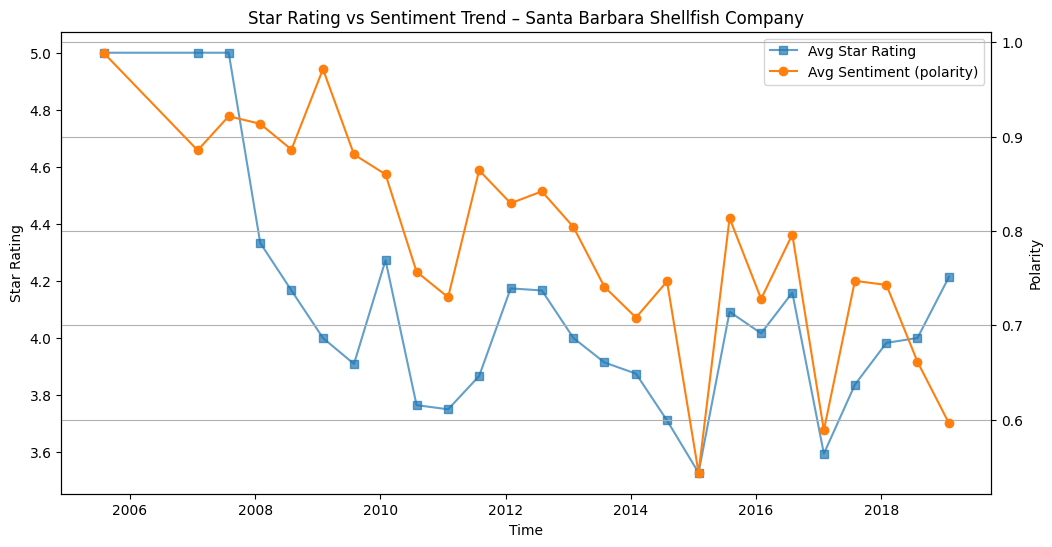

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from collections import Counter
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. User to select business using keyword search

# Get business info
b1 = keyword_search_interactive(top_n=5)
biz_info = business_df[business_df["name"] == b1][
    ["business_id", "name", "city", "state", "stars", "review_count", "categories"]
]
print("\nBusiness info:\n")
display(biz_info)
b1_id = biz_info["business_id"].values[0]

# Sometimes review_subset may not include 'date' → reload from raw file
if "date" not in review_subset.columns:
    print("\n'review_subset' has no date column. Reloading from raw file for this business only...")
    rows = []
    with open(review_path, "r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            if r["business_id"] == b1:
                rows.append({
                    "review_id": r["review_id"],
                    "business_id": r["business_id"],
                    "stars": r["stars"],
                    "text": r["text"],
                    "date": r["date"]
                })
    b1_reviews_df = pd.DataFrame(rows)
else:
    b1_reviews_df = review_subset[review_subset["business_id"] == b1_id].copy()

# Parse date column properly
b1_reviews_df["date"] = pd.to_datetime(b1_reviews_df["date"], errors="coerce")
b1_reviews_df = b1_reviews_df.dropna(subset=["date"]).sort_values("date")

print("\nNumber of reviews:", len(b1_reviews_df))
print("Date range:", b1_reviews_df["date"].min(), "to", b1_reviews_df["date"].max())

# 2. Sentiment Trend using Vadar
if len(b1_reviews_df) != 0:  # not all businesses have reviews
  # Compute polarity (–1 to +1)
  analyzer = SentimentIntensityAnalyzer()
  b1_reviews_df["sentiment"] = b1_reviews_df["text"].apply(lambda t: analyzer.polarity_scores(t))
  b1_reviews_df = pd.concat([b1_reviews_df.drop(['sentiment'], axis=1), b1_reviews_df['sentiment'].apply(pd.Series)], axis=1)
  b1_reviews_df = b1_reviews_df.rename(columns={'compound': 'polarity'})

  # Resample every 6 months → aggregate mean scores
  trend = b1_reviews_df.set_index("date").resample("6M").agg({
      "stars": "mean",
      "polarity": "mean",
      "text": "count"
  }).rename(columns={"text": "review_count"}).dropna()

  # Plot sentiment vs star ratings
  fig, ax1 = plt.subplots(figsize=(12,6))
  l1, = ax1.plot(trend.index, trend["stars"], marker="s",color="#1f77b4", label="Avg Star Rating", alpha=0.7)
  ax2 = ax1.twinx()
  l2, = ax2.plot(trend.index, trend["polarity"], marker="o",color="#ff7f0e", label="Avg Sentiment (polarity)")
  ax1.set_xlabel("Time")
  ax1.set_ylabel("Star Rating")
  ax2.set_ylabel("Polarity")
  lines = [l1, l2]
  labels = [line.get_label() for line in lines]
  ax1.legend(lines, labels, loc="upper right")
  plt.title("Star Rating vs Sentiment Trend – {}".format(biz_info["name"].iloc[0]))
  plt.grid(True)
  plt.show()
else:
  print("No reviews to analyze.")

# Section 4.2: Semantic analysis

In [ ]:
# --- Semantic Trend: TF-IDF distinctive keywords --- (what people talk about)
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def top_tfidf_keywords(docs, n=8):
    docs = [d for d in docs if isinstance(d, str) and d.strip()]
    if not docs:
        return []
    vec = TfidfVectorizer(stop_words="english", max_features=5000)
    X = vec.fit_transform(docs)           # shape: (num_docs, vocab)
    scores = np.asarray(X.sum(axis=0)).ravel()  # total tf-idf per term across the bin
    terms = vec.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:n]
    return [terms[i] for i in top_idx]

semantic_tfidf = (b1_reviews_df
                  .assign(date=pd.to_datetime(b1_reviews_df["date"], errors="coerce"))
                  .dropna(subset=["date"])
                  .set_index("date")
                  .resample("6M")["text"]
                  .apply(lambda x: top_tfidf_keywords(list(x), n=8)))

print("\n=== Semantic Trend (Top TF-IDF Keywords per 6M) ===")
print(semantic_tfidf)



/tmp/ipython-input-3584286783.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("6M")["text"]



=== Semantic Trend (Top TF-IDF Keywords per 6M) ===
date
2005-07-31    [served, meal, wine, followed, garlic, white, ...
2006-01-31                                                   []
2006-07-31                                                   []
2007-01-31    [ve, times, unable, think, tacos, steamed, soc...
2007-07-31    [fresh, lobster, place, crab, different, dishe...
2008-01-31    [tacos, seafood, outside, lobster, like, table...
2008-07-31    [crab, good, seafood, spot, place, sure, butte...
2009-01-31    [crab, came, lobster, calamari, food, minutes,...
2009-07-31    [crab, chowder, good, clam, lobster, food, pla...
2010-01-31    [place, crab, chowder, good, just, time, clam,...
2010-07-31    [crab, place, fresh, great, wait, seafood, mus...
2011-01-31    [great, crab, seafood, chowder, food, rock, br...
2011-07-31    [crab, great, chowder, place, good, best, clam...
2012-01-31    [good, crab, chowder, clam, place, seafood, re...
2012-07-31    [place, crab, good, food, great,

In [ ]:
### added cos pivot table not defined in following cell if this cell is not run
# Convert semantic_tfidf (Series of keyword lists) to a pivot table
from collections import Counter
import pandas as pd

# Each row: time period; each column: keyword; value = frequency count
rows = []
for date, words in semantic_tfidf.items():
    if isinstance(words, (list, np.ndarray)):
        rows.append(pd.Series(Counter(words), name=date))
pivot = pd.DataFrame(rows).fillna(0).T  # transpose → words × dates

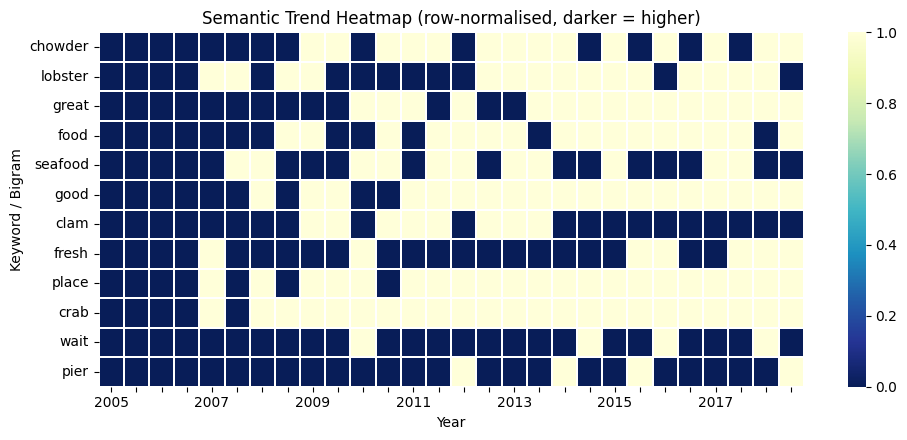

In [ ]:
# --- Clean Semantic Heatmap (Option A, fixed for Timestamp columns) ---
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Row-normalise the pivot (each word scaled 0-1 by its own max)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0).fillna(0)

# Keep only top 12 words that vary the most over time
var = pivot_norm.var(axis=1).sort_values(ascending=False)
keep = var.head(12).index
M = pivot_norm.loc[keep].copy()

# Convert Timestamp columns to string years
years = [col.year if hasattr(col, 'year') else col for col in M.columns]
xtl = [str(y) if i % 4 == 0 else "" for i, y in enumerate(years)]

plt.figure(figsize=(10, 4.5))
sns.heatmap(
    M,
    cmap="YlGnBu_r",
    cbar=True,
    xticklabels=xtl,
    yticklabels=True,
    linewidths=0.3,
    linecolor="white"
)
plt.title("Semantic Trend Heatmap (row-normalised, darker = higher)", fontsize=12)
plt.xlabel("Year")
plt.ylabel("Keyword / Bigram")
plt.tight_layout()
plt.show()






In [ ]:
# ========================== RESCUE CELL: Load reviews for one business + Topic Modeling ==========================
import json, re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 0) CONFIG: set business
# If you have the business NAME:
# b1_name = "Santa Barbara Shellfish Company"
# If you already have b1_id, set it and comment out the name lookup:
# b1_id = "SZU9c8V2GuREDN5KgyHFJw"

# Try to use an existing selection first; otherwise prompt to set one of the two:
try:
    b1_id
except NameError:
    try:
        b1_name
    except NameError:
        raise ValueError("Set either b1_id or b1_name before running this cell.")

# If only name is given, look up id
if 'b1_id' not in globals():
    if 'business_df' not in globals():
        raise ValueError("business_df not found. Load business.json into business_df first.")
    match = business_df.loc[business_df['name'] == b1_name, 'business_id']
    if match.empty:
        raise ValueError(f"Business name not found in business_df: {b1_name}")
    b1_id = match.iloc[0]

print("Using business_id:", b1_id)

# 1) Reload reviews for this business from RAW file (full scan, not subset)
if 'review_path' not in globals():
    raise ValueError("Set review_path to your yelp_academic_dataset_review.json path.")

rows = []
with open(review_path, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if r.get("business_id") == b1_id:
            rows.append({
                "review_id": r.get("review_id"),
                "business_id": r.get("business_id"),
                "stars": r.get("stars"),
                "text": r.get("text"),
                "date": r.get("date"),
            })

b1_reviews_df = pd.DataFrame(rows)
print("Raw rows loaded for this business:", len(b1_reviews_df))

if b1_reviews_df.empty:
    raise ValueError("No reviews found for this business_id. Double-check b1_id or dataset path.")

# 2) Clean/validate columns
b1_reviews_df["date"] = pd.to_datetime(b1_reviews_df["date"], errors="coerce")
b1_reviews_df["text"] = b1_reviews_df["text"].astype(str)

# Drop rows with missing date or trivially empty text
b1_reviews_df["text_trim"] = b1_reviews_df["text"].str.strip()
b1_reviews_df = b1_reviews_df.dropna(subset=["date"])
b1_reviews_df = b1_reviews_df[b1_reviews_df["text_trim"] != ""].copy()
b1_reviews_df = b1_reviews_df.sort_values("date").reset_index(drop=True)
b1_reviews_df = b1_reviews_df.drop(columns=["text_trim"])

print("After cleaning — rows:", len(b1_reviews_df))
print("Date range:", b1_reviews_df["date"].min(), "→", b1_reviews_df["date"].max())
display(b1_reviews_df[["date","stars","text"]].head(3))

# If still empty, bail early with guidance
if b1_reviews_df.empty:
    raise ValueError("Still no usable reviews after cleaning. The reviews may be missing or only whitespace.")

# 3) Build bins (use 12M if 6M is too sparse)
BIN = "6M"    # change to "12M" if the business has sparse reviews
df = b1_reviews_df[["text","date"]].copy()
df["bin"] = pd.to_datetime(df["date"]).dt.to_period(BIN).dt.to_timestamp(how="end")

# 4) TF-IDF (lenient first, then you can tighten later)
texts = df["text"].fillna("").astype(str)

# Start lenient to avoid "empty vocabulary"
vec = TfidfVectorizer(
    stop_words="english",    # ← remove common English stopwords
    max_df=0.95,             # ignore words in >95% of docs
    min_df=2,                # ignore words appearing only once
    ngram_range=(1,2),       # unigrams + bigrams
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"  # keep only alphabetic words of length ≥2
)
X = vec.fit_transform(texts)
terms = vec.get_feature_names_out()
print("TF-IDF shape:", X.shape)

if X.shape[0] == 0 or X.shape[1] == 0:
    raise ValueError("No usable vocabulary after TF-IDF. Inspect texts or relax vectorizer even more.")

# 5) NMF topics
N_TOPICS = 6
nmf = NMF(n_components=N_TOPICS, init="nndsvd", random_state=42, max_iter=400)
W = nmf.fit_transform(X)   # doc → topic weights
H = nmf.components_        # topic → term weights

def top_words_for_topic(topic_row, k=5):
    idx = np.argsort(topic_row)[::-1][:k]
    return [terms[i] for i in idx]

topic_labels = [" / ".join(top_words_for_topic(H[i], 5)) for i in range(N_TOPICS)]
topic_cols = [f"topic_{i}" for i in range(N_TOPICS)]

print("\nTopics discovered:")
for i, lab in enumerate(topic_labels, 1):
    print(f"T{i}: {lab}")

# 6) Aggregate topic weights per time bin (for your widget)
topic_df = pd.DataFrame(W, columns=topic_cols)
topic_df["bin"] = df["bin"].values
per_bin = topic_df.groupby("bin")[topic_cols].mean().sort_index()

HAS_DATE = True  # you’re using real dates → time bins on x-axis
print("\nper_bin shape:", per_bin.shape)


Using business_id: SZU9c8V2GuREDN5KgyHFJw
Raw rows loaded for this business: 2444
After cleaning — rows: 2444
Date range: 2005-07-07 21:56:53 → 2022-01-19 05:21:58


,date,stars,text
0,2005-07-07 21:56:53,5.0,This delightful dining spot is perched at the ...
1,2007-01-15 20:28:42,5.0,I adore you Shellfish Company. I think that I'...
2,2007-02-14 14:58:51,4.0,"Best spot on the wharf. A little dive spot, t..."


TF-IDF shape: (2444, 15588)

Topics discovered:
T1: good / just / wait / shrimp / outside
T2: great / food / service / place / seafood
T3: lobster / roll / lobster roll / bisque / tacos
T4: santa / santa barbara / barbara / uni / fresh
T5: chowder / clam / clam chowder / bowl / bread
T6: crab / rock / rock crab / fresh / special

per_bin shape: (176, 6)


In [ ]:
# ============== Topic Trend Filters ==============
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Shorten labels for plotting
def _short(label, max_len=50):
    s = label.replace(" / ", ", ")
    return s if len(s) <= max_len else s[:max_len-1] + "…"

nice_labels = [_short(l) for l in topic_labels]

# Single-topic plot
def plot_single_topic(per_bin, topic_idx, smoothed=False):
    col = f"topic_{topic_idx}"
    if col not in per_bin.columns:
        raise ValueError(f"Topic index {topic_idx} out of range.")
    y = per_bin[col]
    if smoothed:
        y = y.rolling(window=2, min_periods=1).mean()
    plt.figure(figsize=(10,4))
    plt.plot(per_bin.index, y, marker="o", linewidth=2)
    plt.title(f"T{topic_idx+1}: {nice_labels[topic_idx]}")
    plt.xlabel("Time (6-month bins)" if HAS_DATE else "Bin (each ≈ 10 reviews)")
    plt.ylabel("Average Topic Weight")
    plt.grid(True, alpha=.3)
    plt.tight_layout()
    plt.show()

# Widget: choose a topic and smooth option
topic_opts = [(f"T{i+1}: {nice_labels[i]}", i) for i in range(len(topic_cols))]
dd_topic = widgets.Dropdown(options=topic_opts, description="Topic:", value=0)
chk_smooth = widgets.Checkbox(value=False, description="Smooth (rolling=2)")
ui = widgets.HBox([dd_topic, chk_smooth])

out = widgets.Output()
display(ui, out)

def _update_single(*_):
    with out:
        out.clear_output()
        plot_single_topic(per_bin, dd_topic.value, smoothed=chk_smooth.value)

dd_topic.observe(_update_single, names="value")
chk_smooth.observe(_update_single, names="value")
_update_single()


Output()

# Section 4.3 Aspect-based trend analysis

Setup for aspect extraction

In [ ]:
import re
import numpy as np

try:
    analyzer
except NameError:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()

BIN = "6M"

aspects = [
    "service", "food", "price", "staff", "wait", "ambience",
    "menu", "quality", "portion", "clean"
]

b1_reviews_df["text_lc"] = b1_reviews_df["text"].astype(str).str.lower()

b1_reviews_df["bin"] = pd.to_datetime(b1_reviews_df["date"]).dt.to_period(BIN).dt.to_timestamp(how="end")

for a in aspects:
    b1_reviews_df[f"has_{a}"] = b1_reviews_df["text_lc"].str.contains(rf"\b{re.escape(a)}\b", regex=True)

if "polarity" not in b1_reviews_df.columns:
    b1_reviews_df["polarity"] = b1_reviews_df["text"].apply(lambda t: analyzer.polarity_scores(str(t))["compound"])

In [ ]:
# Helpers
import math
from matplotlib.dates import DateFormatter

def get_aspect_cols(df, prefix="has_"):
    return [c for c in df.columns if c.startswith(prefix)]

def aggregate_per_bin(df, aspect_cols):
    return df.groupby("bin")[aspect_cols].sum().sort_index()

def row_normalize_rows(df):
    # df rows = aspects, cols = bins
    m = df.copy()
    maxima = m.max(axis=1).replace(0, 1)
    return m.div(maxima, axis=0).fillna(0)

def smooth_series(series, roll_win=5, upsample=6):
    s = series.copy().astype(float).sort_index()
    if not isinstance(s.index, pd.DatetimeIndex):
        try:
            s.index = pd.to_datetime(s.index)
        except Exception:
            pass
    s_interp = s.interpolate(method='time', limit_direction='both')
    s_roll = s_interp.rolling(window=roll_win, min_periods=1, center=True).mean()
    valid_idx = s_roll.dropna().index
    if upsample and upsample > 1 and len(valid_idx) >= 3:
        times_ns = np.array([t.value for t in valid_idx])
        y_clean = s_roll.loc[valid_idx].values
        x_new = np.linspace(times_ns.min(), times_ns.max(), len(y_clean) * upsample)
        y_new = np.interp(x_new, times_ns, y_clean)
        idx_new = pd.to_datetime(x_new.astype('int64'))
        return pd.Series(y_new, index=idx_new)
    return s_roll

In [ ]:
# Config knobs
aspect_prefix = "has_"
smoothing_window = 3    # rolling on counts before normalization (set None or 1 to disable)
roll_win = 5            # rolling for curve smoothing
upsample = 6            # densify curves for smooth look
cols_per_row = 4        # subplot columns in grid

# Prepare matrix like the heatmap did: rows = aspects, cols = time bins
aspect_cols = get_aspect_cols(b1_reviews_df, prefix=aspect_prefix)
freq = aggregate_per_bin(b1_reviews_df, aspect_cols)

# Smoothing on counts before row-normalize
if smoothing_window and smoothing_window > 1:
    freq_plot = freq.rolling(window=smoothing_window, min_periods=1).mean()
else:
    freq_plot = freq.copy()

M = freq_plot.T.fillna(0)       # rows=aspects, cols=bins
M_norm = row_normalize_rows(M)  # 0-1 per aspect (comparable shapes)

# Order aspects by total mentions
order = freq.sum(axis=0).sort_values(ascending=False).index.tolist()
ordered_aspects = [c for c in order if c in M_norm.index]

Aspect mention frequency trend

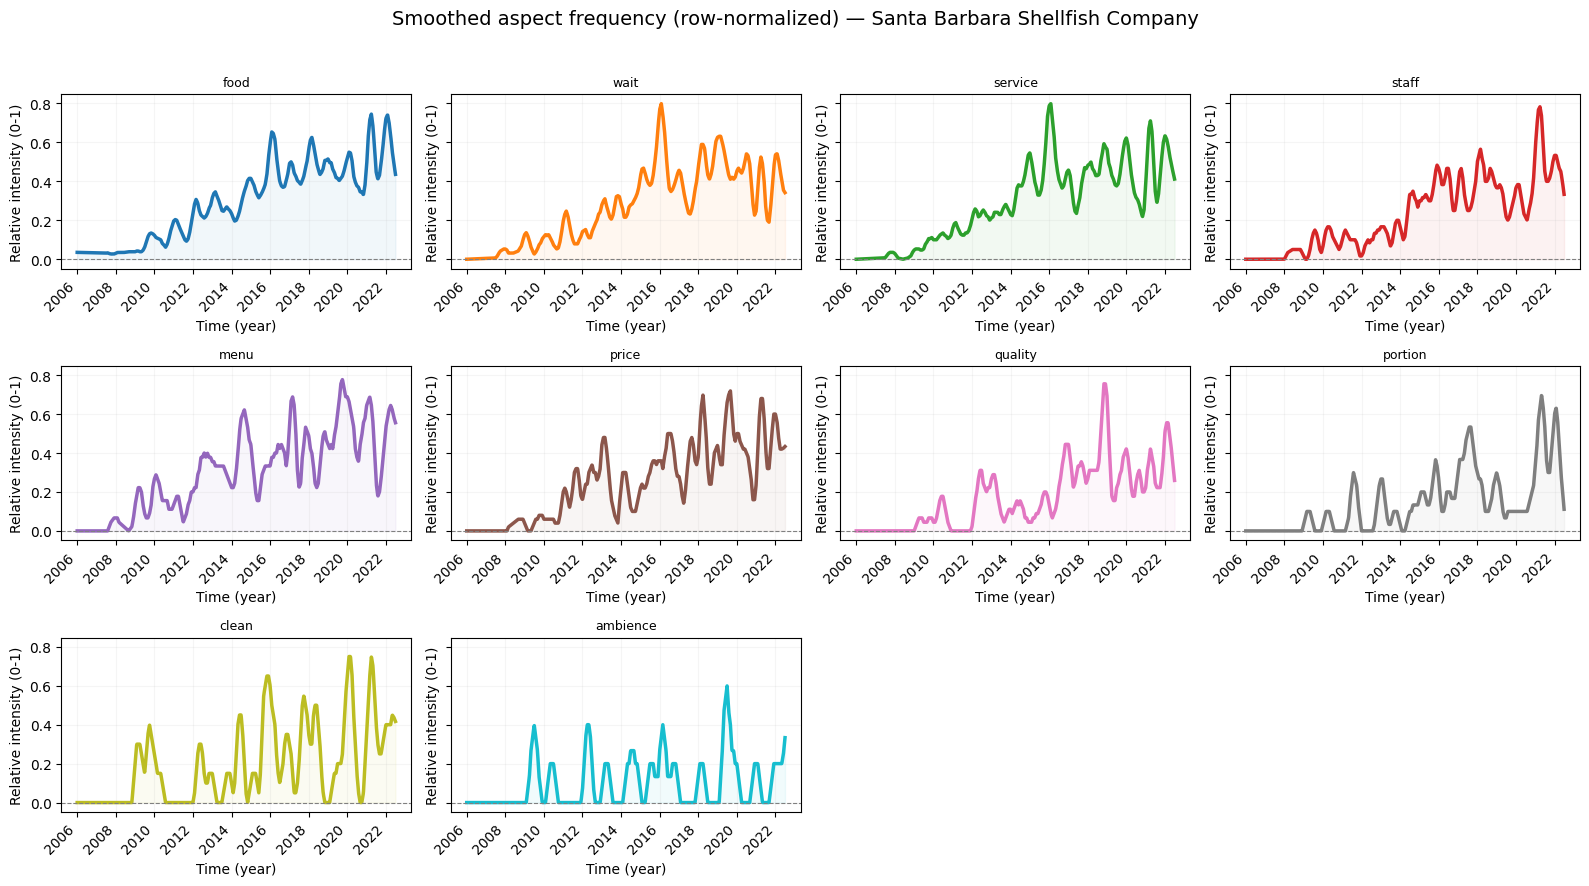

In [ ]:
# Layout and global axis limits
n = len(ordered_aspects)
rows = math.ceil(n / cols_per_row)
fig, axes = plt.subplots(rows, cols_per_row, figsize=(4*cols_per_row, 3*rows), sharex=False, sharey=True)
axes = axes.flatten()

# Precompute smoothed series for y-limits
smoothed_list = []
for a in ordered_aspects:
    sm = smooth_series(M_norm.loc[a], roll_win=roll_win, upsample=upsample)
    smoothed_list.append(sm)
all_vals = np.concatenate([s.values for s in smoothed_list if len(s)>0]) if smoothed_list else np.array([0.0])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
yrange = ymax - ymin if ymax > ymin else 1.0
ymin -= 0.06 * yrange; ymax += 0.06 * yrange

# Plot each aspect in its subplot
for i, a in enumerate(ordered_aspects):
    ax = axes[i]
    sm = smoothed_list[i]
    label = a.replace(aspect_prefix, "")
    if len(sm) == 0:
        ax.text(0.5, 0.5, "no data", ha='center', va='center', transform=ax.transAxes)
    else:
        ax.plot(sm.index, sm.values, color=f"C{i%10}", linewidth=2.5)
        ax.fill_between(sm.index, sm.values, alpha=0.06, color=f"C{i%10}")
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Time (year)")
    ax.set_ylabel("Relative intensity (0-1)")
    try:
        ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    except Exception:
        pass
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_horizontalalignment('right')
    ax.grid(alpha=0.12)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Smoothed aspect frequency (row-normalized) — {biz_info['name'].iloc[0]}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Aspect sentiment trend

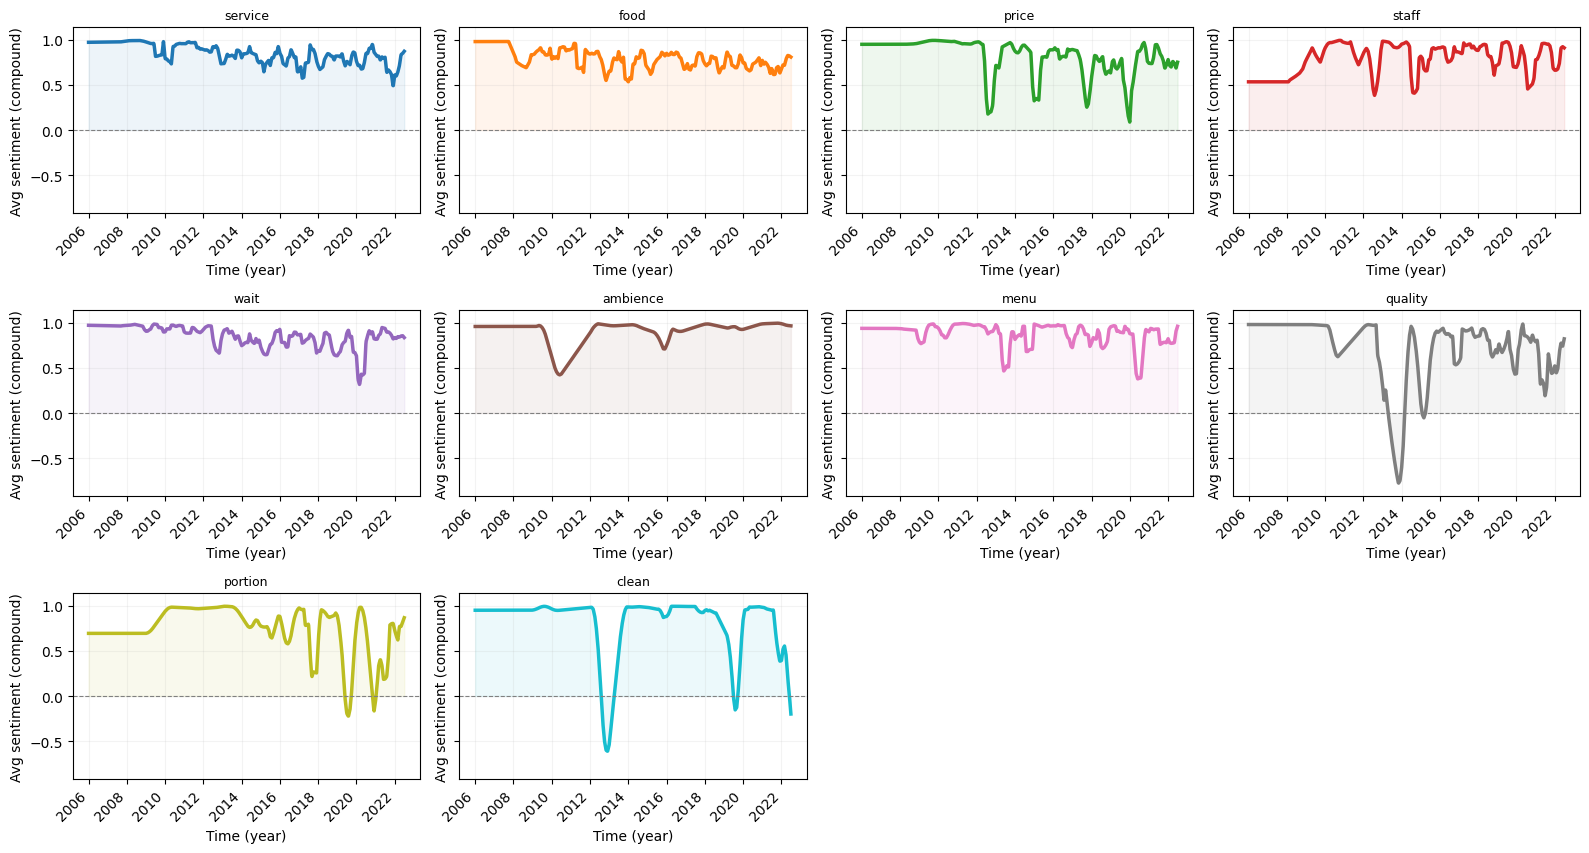

In [ ]:
# Define build_sent_trend
def build_sent_trend(df, aspects_list):
    rows = []
    for a in aspects_list:
        col = f"has_{a}"
        if col not in df.columns:
            continue
        tmp = df[df[col]]
        if tmp.empty:
            continue
        rows.append(tmp.groupby("bin")["polarity"].mean().rename(col))
    return pd.concat(rows, axis=1).sort_index() if rows else pd.DataFrame()

sent_trend = build_sent_trend(b1_reviews_df, aspects)

# Plot
n = len(sent_trend.columns)
cols = 4
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharex=False, sharey=True)
axes = axes.flatten()

smoothed_list = [smooth_series(sent_trend[c], roll_win=roll_win, upsample=upsample) for c in sent_trend.columns]
all_vals = np.concatenate([s.values for s in smoothed_list if len(s) > 0]) if smoothed_list else np.array([0.0])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
yrange = ymax - ymin if ymax > ymin else 1.0
pad = 0.08 * yrange
ymin, ymax = ymin - pad, ymax + pad

for i, (col, sm) in enumerate(zip(sent_trend.columns, smoothed_list)):
    ax = axes[i]
    label = col.replace("has_", "")
    if len(sm) == 0:
        ax.text(0.5, 0.5, "no data", ha='center', va='center', transform=ax.transAxes)
    else:
        ax.plot(sm.index, sm.values, color=f"C{i%10}", linewidth=2.5)
        ax.fill_between(sm.index, sm.values, alpha=0.08, color=f"C{i%10}")
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Time (year)")
    ax.set_ylabel("Avg sentiment (compound)")
    try:
        ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    except Exception:
        pass
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_horizontalalignment('right')
    ax.grid(alpha=0.15)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Rating impact of aspect mentions over time

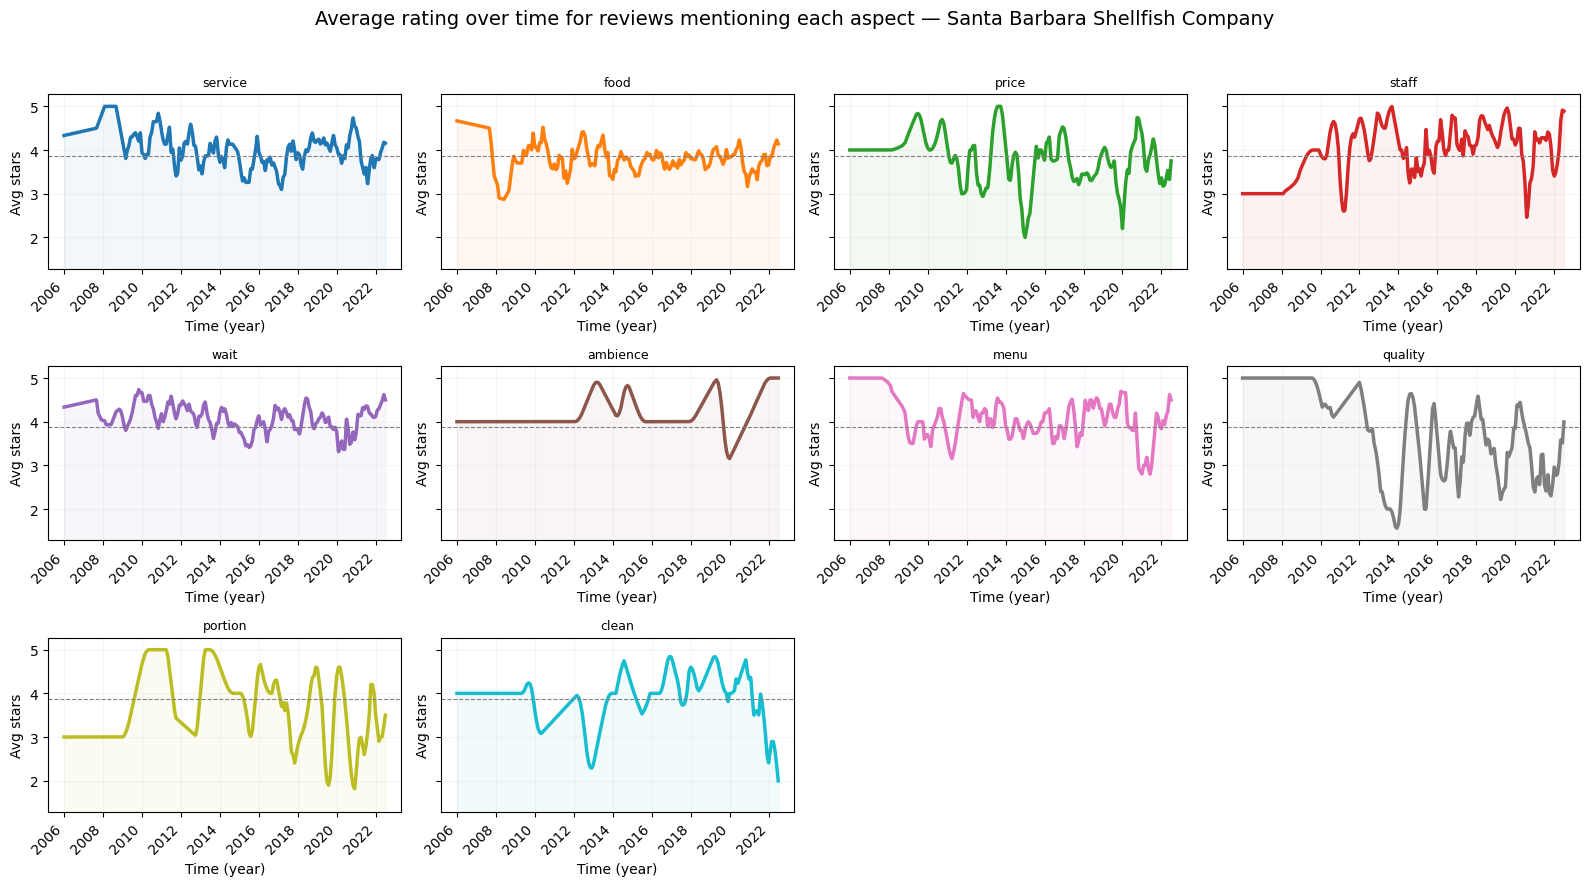

In [ ]:
# Build per-aspect mean-rating series
rows = []
for a in aspects:
    col = f"has_{a}"
    if col in b1_reviews_df.columns:
        tmp = b1_reviews_df[b1_reviews_df[col]]
        if not tmp.empty:
            rows.append(tmp.groupby("bin")["stars"].mean().rename(a))
rating_trend = pd.concat(rows, axis=1).sort_index() if rows else pd.DataFrame()
if rating_trend.empty:
    raise ValueError("No aspect rating series found. Ensure `aspects` and `b1_reviews_df` exist and have data.")

# Layout and plotting (one subplot per aspect only)
n = len(rating_trend.columns)
cols = 4
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharex=False, sharey=True)
axes = axes.flatten()

smoothed_list = [smooth_series(rating_trend[a], roll_win=roll_win, upsample=upsample) for a in rating_trend.columns]
all_vals = np.concatenate([s.values for s in smoothed_list if len(s) > 0]) if smoothed_list else np.array([0.0])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
yrange = ymax - ymin if ymax > ymin else 1.0
pad = 0.08 * yrange
ymin, ymax = ymin - pad, ymax + pad

global_mean = rating_trend.stack().mean()

for i, (a, sm) in enumerate(zip(rating_trend.columns, smoothed_list)):
    ax = axes[i]
    label = a.replace("has_", "")
    if len(sm) == 0:
        ax.text(0.5, 0.5, "no data", ha='center', va='center', transform=ax.transAxes)
    else:
        ax.plot(sm.index, sm.values, color=f"C{i%10}", linewidth=2.5)
        ax.fill_between(sm.index, sm.values, alpha=0.06, color=f"C{i%10}")
    ax.axhline(global_mean, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Time (year)")
    ax.set_ylabel("Avg stars")
    try:
        ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    except Exception:
        pass
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_horizontalalignment('right')
    ax.grid(alpha=0.12)


for j in range(n, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Average rating over time for reviews mentioning each aspect — {biz_info['name'].iloc[0]}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Aspect co-mention heatmap

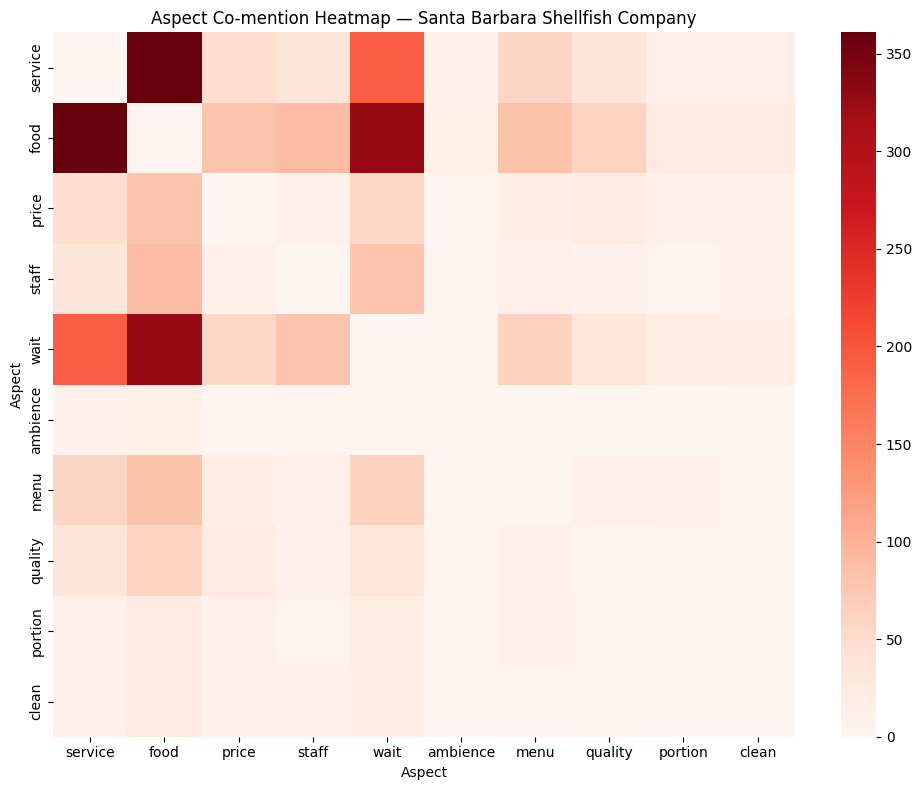

In [ ]:
has_cols = [f"has_{a}" for a in aspects]
M = b1_reviews_df[has_cols].astype(int).values
co = (M.T @ M)  # co-mention matrix

co_df = pd.DataFrame(co, index=aspects, columns=aspects)
np.fill_diagonal(co_df.values, 0)  # removing self-counts for clearer visual

plt.figure(figsize=(10,8))
sns.heatmap(co_df, cmap="Reds", annot=False)
plt.title(f"Aspect Co-mention Heatmap — {biz_info['name'].iloc[0]}")
plt.xlabel("Aspect")
plt.ylabel("Aspect")
plt.tight_layout()
plt.show()

# Section 5: Application

In [ ]:
# Simple input based UI
keyword_search_interactive(top_n=5)

In [ ]:
# Boon Wee's testing application
# Application uses punkt

import nltk
from nltk.tokenize import sent_tokenize

def detect_user_keyword_sentences(max_samples=5):
    """Interactive tool: detect sentences containing a user-entered keyword in reviews of a chosen business."""

    # Step 1: Let user choose a business
    current_biz_input = input("\nEnter the name (or part of name) of the business to analyze: ").strip()
    matches = [nm for nm in business_subset["name"].tolist() if current_biz_input.lower() in nm.lower()]

    if not matches:
        print("No matching businesses found. Try again.")
        return

    if len(matches) > 1:
        print("\nMultiple matches found:")
        for i, m in enumerate(matches, start=1):
            print(f"[{i}] {m}")
        choice = input("Enter the number of the business you want: ")
        try:
            current_biz_resolved = matches[int(choice)-1]
        except:
            current_biz_resolved = matches[0]
    else:
        current_biz_resolved = matches[0]

    # Step 2: Ask user for keyword
    keyword = input("\nEnter the keyword to search for in the reviews (e.g., 'better', 'compared'): ").strip().lower()

    # Step 3: Get reviews of this business
    biz_id = business_subset[business_subset["name"] == current_biz_resolved]["business_id"].values[0]
    reviews = review_subset[review_subset["business_id"] == biz_id]["text"].tolist()

    # Step 4: Detect sentences with keyword
    keyword_sents = []
    for review in reviews:
        sentences = sent_tokenize(review)
        for sent in sentences:
            if keyword in sent.lower():
                keyword_sents.append(sent)

    # Step 5: Show results
    print(f"\n=== Sentences Containing '{keyword}' in Reviews for {current_biz_resolved} ===")
    if keyword_sents:
        for i, sent in enumerate(keyword_sents[:max_samples], start=1):
            print(f"{i}. {sent}")
    else:
        print(f"No sentences containing '{keyword}' found in reviews of '{current_biz_resolved}'.")


# Run the interactive tool
detect_user_keyword_sentences(max_samples=5)


Enter the name (or part of name) of the business to analyze: sushi

Multiple matches found:
[1] Sushi Tyme
[2] Sakana Sushi Bar & Japanese
[3] Hibachi Steak House & Sushi Bar
[4] Q's Billiard Club & Sushi-a-go-go
[5] Sun Sushi
[6] Piranha Restaurant & Sushi Bar
[7] Kai Sushi Shabu-Shabu
[8] Arigato Sushi
[9] Sushi Cafe
[10] Yume Sushi Japanese Restaurant
[11] Sushi GoGo
[12] Sushi Teri House
[13] Ahi Sushi
[14] Shintori Sushi Factory
[15] Sushi Bar 29
Enter the number of the business you want: 2

Enter the keyword to search for in the reviews (e.g., 'better', 'compared'): compared

=== Sentences Containing 'compared' in Reviews for Sakana Sushi Bar & Japanese ===
1. They are on the pricier side compared to your average sushi restaurant, but not by much.
2. It is frequently compared to Nobu, and you can instantly see why.
3. Compared to the others the sushi is so, so, so good!
